# Resistance-oriented generative model for MALDI-TOF spectra

This notebook implements the corrected version of the generative model.

The input of the model is still the MALDI-TOF spectrum:

However, instead of learning a latent space mainly optimized for spectral reconstruction, the model is forced to learn a resistance-oriented latent variable `w`.

The corrected direction is:
$
x \rightarrow w \rightarrow \hat{y}
$

and then:
$
w \rightarrow \hat{x}
$

where:

- $x$ is the input MALDI-TOF spectrum.
- $w$ is a latent representation extracted from the spectrum.
- $\hat{y}$ is the predicted AMR profile.
- $\hat{x}$ is the reconstructed spectrum.

The key idea is that the AMR prediction loss is the main loss, and the spectral reconstruction loss acts as a secondary regularization term. This prevents the high-dimensional spectrum from dominating the optimization.

So the model is 

$
q_\phi(w|x), \quad p_\theta(y|w), \quad p_\theta(x|w)
$

## 1. Imports and reproducibility

We load the libraries needed for the notebook.

We use:

- `PyTorch` for the model.
- `sklearn` for train/test split, AUC and t-SNE.
- `matplotlib` for plots.
- `pickle` to load the dataset.

In [15]:
import os
import pickle
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Configuration

The most important hyperparameters are the loss weights:

- `LAMBDA_AMR`: weight for AMR prediction. This should be high, because we want `w` to be resistance-oriented.
- `LAMBDA_SPEC`: weight for spectrum reconstruction. This should be lower, because spectrum reconstruction is secondary.
- `BETA_W`: weight for the variational KL regularization.

The objective is:


$$\mathcal{L}
=
\lambda_{AMR}\mathcal{L}_{AMR}(y,\hat{y})
+
\lambda_{spec}\mathcal{L}_{spec}(x,\hat{x})
+
\beta_w KL(q_\phi(w|x)||p(w))
$$

with:

$
\lambda_{AMR} > \lambda_{spec}
$

In [ ]:
DATA_PATH = "COMBINED_MARISMA_DRIAMS.pkl"
TARGET_SPECIES = "Klebsiella_Pneumoniae"

TARGET_ANTIBIOTICS = [
    "Ciprofloxacin",
    "Ceftriaxone",
    "Piperacillin-Tazobactam",
    "Cefepime",
    "Imipenem",
    "Meropenem"
]

# Latent dimension for the resistance-oriented representation.
LATENT_DIM_W = 64

# Neural network sizes.
# ENC_H1 and ENC_H2 are intentionally moderate. If your spectra have many bins,
# you may increase them, but start simple to avoid overfitting.
ENC_H1 = 512
ENC_H2 = 128
DEC_Y_H = 64
DEC_X_H1 = 256
DEC_X_H2 = 1024

# Training.
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3
TEST_SIZE = 0.3

# Preprocessing.
TOP_K_REMOVE = 0
EPS = 1e-8

# Loss weights.
# AMR is intentionally prioritized over spectrum reconstruction.
LAMBDA_AMR = 5.0
LAMBDA_SPEC = 0.05
BETA_W = 1e-4

# t-SNE.
TSNE_PERPLEXITY = 30
TSNE_N_ITER = 1000

## 3. Load and preprocess the data

The file `COMBINED_MARISMA_DRIAMS.pkl` should contain at least:

- `data`: MALDI-TOF spectra, with shape `[n_samples, n_mz_bins]`.
- `label`: bacterial species for each sample.
- `amr`: AMR matrix, with shape `[n_samples, n_antibiotics]`.
- `antibiotics`: antibiotic names in the same order as the columns of `amr`.

Preprocessing steps:

1. Remove the most intense peaks if `TOP_K_REMOVE > 0`.
2. Filter by the target species.
3. Select only the target antibiotics.

Missing AMR labels can be represented as `NaN`. They will be ignored in the AMR loss.

In [ ]:
def remove_top_k_peaks_per_spectrum(X, top_k=10):
    """Remove the top-k most intense peaks in each spectrum."""
    X_new = X.copy()
    if top_k <= 0:
        return X_new
    for i in range(X_new.shape[0]):
        idx = np.argpartition(X_new[i], -top_k)[-top_k:]
        X_new[i, idx] = 0
    return X_new

with open(DATA_PATH, "rb") as f:
    payload = pickle.load(f)

X = payload["data"]
y_species = payload["label"]
amr = payload["amr"]
antibiotics = list(payload["antibiotics"])

print("Raw X shape:", X.shape)
print("Raw AMR shape:", amr.shape)
print("Num antibiotics in file:", len(antibiotics))

X = remove_top_k_peaks_per_spectrum(X, TOP_K_REMOVE)

mask_species = np.array(y_species) == TARGET_SPECIES
X = X[mask_species]
amr = amr[mask_species]

ab_idx = [antibiotics.index(a) for a in TARGET_ANTIBIOTICS]
amr = amr[:, ab_idx]
amr = amr.astype(np.float32)

num_antibiotics = len(TARGET_ANTIBIOTICS)
input_dim = X.shape[1]

print("Filtered X shape:", X.shape)
print("Filtered AMR shape:", amr.shape)
print("Input spectrum dimension:", input_dim)
print("Target antibiotics:", TARGET_ANTIBIOTICS)
print("Missing AMR labels:", np.isnan(amr).sum())

Raw X shape: (66832, 6000)
Raw AMR shape: (66832, 104)
Num antibiotics in file: 104
Filtered X shape: (19265, 6000)
Filtered AMR shape: (19265, 6)
Input spectrum dimension: 6000
Target antibiotics: ['Ciprofloxacin', 'Ceftriaxone', 'Piperacillin-Tazobactam', 'Cefepime', 'Imipenem', 'Meropenem']
Missing AMR labels: 34457


## 4. Train/test split and Dataset

Each sample contains:

- `x`: MALDI-TOF spectrum.
- `y`: binary AMR profile for the selected antibiotics.

The encoder receives **only** `x`.

The vector `y` is never passed as an input to the model. It is only used as the target for the supervised AMR loss.

Correct route:

$$
x \rightarrow w \rightarrow \hat{y}
$$

and:

$$
w \rightarrow \hat{x}
$$


In [18]:
train_idx, test_idx = train_test_split(
    np.arange(len(X)),
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True
)

X_train, X_test = X[train_idx], X[test_idx]
amr_train, amr_test = amr[train_idx], amr[test_idx]

print("Train size:", len(X_train))
print("Test size :", len(X_test))

class ResistanceSpectrumDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(
    ResistanceSpectrumDataset(X_train, amr_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

test_loader = DataLoader(
    ResistanceSpectrumDataset(X_test, amr_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

Train size: 13485
Test size : 5780


## 5. Model definition

The model implements:

$$
q_\phi(w \mid x)
$$

$$
p_\theta(y \mid w)
$$

$$
p_\theta(x \mid w)
$$

In words:

1. **Spectrum encoder**: receives the MALDI-TOF spectrum `x` and produces a variational distribution for `w`.
2. **Resistance decoder**: predicts the AMR profile from `w`.
3. **Spectrum decoder**: reconstructs the spectrum from the same `w`.

The important point is that `w` is inferred from the spectrum, but it is strongly supervised by the AMR prediction loss. Therefore, `w` should capture the spectral information that is useful for resistance, instead of being dominated by general spectral reconstruction.

In [19]:
class ResistanceOrientedVAE(nn.Module):
    def __init__(self, input_dim, num_antibiotics):
        super().__init__()

        self.input_dim = input_dim
        self.num_antibiotics = num_antibiotics

        # ====================================================
        # Encoder q(w | x)
        # ====================================================
        # IMPORTANT:
        # The encoder receives the MALDI-TOF spectrum x.
        # It does NOT receive the real AMR labels y.
        # Therefore, w is inferred from the spectrum.
        # ====================================================

        self.enc_w = nn.Sequential(
            nn.Linear(input_dim, ENC_H1),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(ENC_H1, ENC_H2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.w_mu = nn.Linear(ENC_H2, LATENT_DIM_W)
        self.w_logvar = nn.Linear(ENC_H2, LATENT_DIM_W)

        # ====================================================
        # AMR decoder p(y | w)
        # ====================================================
        # This branch predicts antibiotic resistance from w.
        # This is the main supervised task.
        # ====================================================

        self.dec_y = nn.Sequential(
            nn.Linear(LATENT_DIM_W, DEC_Y_H),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(DEC_Y_H, num_antibiotics)
        )

        # ====================================================
        # Spectrum decoder p(x | w)
        # ====================================================
        # This branch reconstructs the input spectrum from the
        # same resistance-oriented latent variable w.
        # ====================================================

        self.dec_x = nn.Sequential(
            nn.Linear(LATENT_DIM_W, DEC_X_H1),
            nn.ReLU(),
            nn.Linear(DEC_X_H1, DEC_X_H2),
            nn.ReLU()
        )

        self.presence_head = nn.Linear(DEC_X_H2, input_dim)
        self.mu_head = nn.Linear(DEC_X_H2, input_dim)
        self.sig_head = nn.Linear(DEC_X_H2, input_dim)

    def reparam(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + eps * torch.exp(0.5 * logvar)

    def forward(self, x):
        # ====================================================
        # 1. Encode spectrum into resistance-oriented latent w
        # ====================================================

        h = self.enc_w(x)

        w_mu = self.w_mu(h)
        w_logvar = self.w_logvar(h)

        w = self.reparam(w_mu, w_logvar)

        # ====================================================
        # 2. Predict AMR profile from w
        # ====================================================

        y_logits = self.dec_y(w)

        # ====================================================
        # 3. Reconstruct spectrum from w
        # ====================================================

        hx = self.dec_x(w)

        pres_logits = self.presence_head(hx)
        mu_x = self.mu_head(hx)
        sig_x = F.softplus(self.sig_head(hx)) + 1e-4

        return {
            "w": w,
            "w_mu": w_mu,
            "w_logvar": w_logvar,
            "y_logits": y_logits,
            "pres_logits": pres_logits,
            "mu_x": mu_x,
            "sig_x": sig_x
        }


model = ResistanceOrientedVAE(
    input_dim=input_dim,
    num_antibiotics=num_antibiotics
).to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=LR)

print(model)

ResistanceOrientedVAE(
  (enc_w): Sequential(
    (0): Linear(in_features=6000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (w_mu): Linear(in_features=128, out_features=64, bias=True)
  (w_logvar): Linear(in_features=128, out_features=64, bias=True)
  (dec_y): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
  (dec_x): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1024, bias=True)
    (3): ReLU()
  )
  (presence_head): Linear(in_features=1024, out_features=6000, bias=True)
  (mu_head): Linear(in_features=1024, out_features=6000, bias=True)
  (sig_head): Linear(in_features=1024, out_features=6000, bia

## 6. Loss functions

The loss combines three terms:
$$
\mathcal{L}
=
\lambda_{AMR}\mathcal{L}_{AMR}
+
\lambda_{spec}\mathcal{L}_{spec}
+
\beta_w KL(q(w|x)||p(w))
$$

The AMR loss uses the true AMR labels `y` only as targets. Missing values are masked.

Important:

`y` is **never** passed into the model. It is only used to compute the loss.

In [20]:
def prepare_y_target(y):
    """
    Prepare AMR targets for masked loss.

    y is used only as target.
    It is never passed into the model.
    """
    y_mask = (~torch.isnan(y)).float()
    y_filled = torch.nan_to_num(y, nan=0.0)
    return y_mask, y_filled


def kl_normal(mu, logvar):
    """KL(q(w|x) || N(0, I)), averaged over the batch."""
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def masked_bce_with_logits(logits, targets, mask):
    """Binary cross entropy only on observed AMR labels."""
    loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    denom = mask.sum().clamp_min(1.0)
    return (loss * mask).sum() / denom


def focal_loss_masked(logits, targets, mask, alpha=0.25, gamma=2.0):
    """Optional focal loss for imbalanced AMR labels, with missing-value masking."""
    p = torch.sigmoid(logits)
    pt = torch.where(targets == 1, p, 1 - p)
    alpha_t = torch.where(targets == 1, alpha, 1 - alpha)
    loss = -alpha_t * (1 - pt).pow(gamma) * torch.log(pt + EPS)
    denom = mask.sum().clamp_min(1.0)
    return (loss * mask).sum() / denom


def spectrum_hurdle_loss(x, pres_logits, mu_x, sig_x):
    """
    Hurdle-like reconstruction loss for sparse MALDI spectra.

    1. BCE for peak presence/absence.
    2. Gaussian negative log-likelihood only for positive peaks.
    """
    peak_mask = (x > 0).float()

    bce_presence = F.binary_cross_entropy_with_logits(
        pres_logits,
        peak_mask,
        reduction="none"
    )

    gaussian_nll = ((x - mu_x) ** 2) / (2 * sig_x ** 2) + torch.log(sig_x)
    loss = bce_presence + gaussian_nll * peak_mask
    return loss.mean()


def kl_anneal(epoch, warmup=30):
    """Gradually increase the KL term during the first warmup epochs."""
    return min(1.0, epoch / warmup)

## 7. Evaluation helpers


In [21]:
def safe_auc(y_true, y_score):
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_score = y_score[mask]

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan


def compute_aucs(y_true, y_score, antibiotic_names):
    aucs = {}
    for j, ab in enumerate(antibiotic_names):
        aucs[ab] = safe_auc(y_true[:, j], y_score[:, j])
    global_auc = safe_auc(y_true.reshape(-1), y_score.reshape(-1))
    return aucs, global_auc


@torch.no_grad()
def collect_outputs(model, loader):
    model.eval()

    y_true_all = []
    y_prob_all = []
    w_mu_all = []
    x_true_all = []
    x_mu_all = []

    for x, y in loader:
        x = x.to(DEVICE)

        # IMPORTANT:
        # Evaluation receives only x.
        # y is not passed into the model.
        out = model(x)
        y_prob = torch.sigmoid(out["y_logits"])

        y_true_all.append(y.numpy())
        y_prob_all.append(y_prob.cpu().numpy())
        w_mu_all.append(out["w_mu"].cpu().numpy())
        x_true_all.append(x.cpu().numpy())
        x_mu_all.append(out["mu_x"].cpu().numpy())

    return {
        "y_true": np.concatenate(y_true_all, axis=0),
        "y_prob": np.concatenate(y_prob_all, axis=0),
        "w_mu": np.concatenate(w_mu_all, axis=0),
        "x_true": np.concatenate(x_true_all, axis=0),
        "x_mu": np.concatenate(x_mu_all, axis=0),
    }


def make_tsne(data, perplexity=30, n_iter=1000, seed=42):
    """Compatibility wrapper for different sklearn versions."""
    perplexity = min(perplexity, max(5, (len(data) - 1) // 3))
    kwargs = dict(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=seed,
    )
    try:
        return TSNE(max_iter=n_iter, **kwargs).fit_transform(data)
    except TypeError:
        return TSNE(n_iter=n_iter, **kwargs).fit_transform(data)

## 8. Training loop

For each batch:

1. The model receives only the spectrum `x`.
2. It encodes `x` into `w`.
3. It predicts AMR labels $$\hat{y}$$ from `w`.
4. It reconstructs the spectrum $$\hat{x}$$ from `w`.
5. The true AMR vector `y` is used only to compute the AMR loss.


In [22]:
history = {
    "train_loss": [],
    "train_amr_loss": [],
    "train_spec_loss": [],
    "train_kl_w": [],
    "test_global_auc": []
}

USE_FOCAL_LOSS = False

for ep in range(EPOCHS):
    model.train()

    running_loss = 0.0
    running_amr = 0.0
    running_spec = 0.0
    running_kl = 0.0

    beta_w = kl_anneal(ep, warmup=30) * BETA_W

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        opt.zero_grad()

        # IMPORTANT:
        # The model receives only x.
        # y is used only as target in the AMR loss.
        out = model(x)

        y_mask, y_filled = prepare_y_target(y)

        if USE_FOCAL_LOSS:
            l_amr = focal_loss_masked(
                out["y_logits"],
                y_filled,
                y_mask
            )
        else:
            l_amr = masked_bce_with_logits(
                out["y_logits"],
                y_filled,
                y_mask
            )

        l_spec = spectrum_hurdle_loss(
            x,
            out["pres_logits"],
            out["mu_x"],
            out["sig_x"]
        )

        l_kl = kl_normal(out["w_mu"], out["w_logvar"])

        loss = (
            LAMBDA_AMR * l_amr
            + LAMBDA_SPEC * l_spec
            + beta_w * l_kl
        )

        loss.backward()
        opt.step()

        running_loss += loss.item()
        running_amr += l_amr.item()
        running_spec += l_spec.item()
        running_kl += l_kl.item()

    avg_loss = running_loss / max(1, len(train_loader))
    avg_amr = running_amr / max(1, len(train_loader))
    avg_spec = running_spec / max(1, len(train_loader))
    avg_kl = running_kl / max(1, len(train_loader))

    test_out = collect_outputs(model, test_loader)
    test_aucs, test_global_auc = compute_aucs(
        test_out["y_true"],
        test_out["y_prob"],
        TARGET_ANTIBIOTICS
    )

    history["train_loss"].append(avg_loss)
    history["train_amr_loss"].append(avg_amr)
    history["train_spec_loss"].append(avg_spec)
    history["train_kl_w"].append(avg_kl)
    history["test_global_auc"].append(test_global_auc)

    auc_msg = " | ".join(
        [
            f"{ab[:12]}: {test_aucs[ab]:.3f}"
            if not np.isnan(test_aucs[ab])
            else f"{ab[:12]}: nan"
            for ab in TARGET_ANTIBIOTICS
        ]
    )

    print(
        f"Epoch {ep:02d} | "
        f"Loss {avg_loss:.4f} | "
        f"AMR {avg_amr:.4f} | "
        f"Spec {avg_spec:.4f} | "
        f"KLw {avg_kl:.4f} | "
        f"Global AUC {test_global_auc:.4f} | "
        f"{auc_msg}"
    )

Epoch 00 | Loss 1.7607 | AMR 0.3494 | Spec 0.2726 | KLw 3.1192 | Global AUC 0.8054 | Ciprofloxaci: 0.652 | Ceftriaxone: 0.744 | Piperacillin: 0.672 | Cefepime: 0.688 | Imipenem: 0.740 | Meropenem: 0.716
Epoch 01 | Loss 1.5177 | AMR 0.3031 | Spec 0.0449 | KLw 1.8364 | Global AUC 0.8320 | Ciprofloxaci: 0.726 | Ceftriaxone: 0.776 | Piperacillin: 0.705 | Cefepime: 0.738 | Imipenem: 0.794 | Meropenem: 0.785
Epoch 02 | Loss 1.3751 | AMR 0.2747 | Spec 0.0360 | KLw 2.1133 | Global AUC 0.8433 | Ciprofloxaci: 0.739 | Ceftriaxone: 0.794 | Piperacillin: 0.742 | Cefepime: 0.758 | Imipenem: 0.792 | Meropenem: 0.795
Epoch 03 | Loss 1.2822 | AMR 0.2562 | Spec 0.0239 | KLw 2.2251 | Global AUC 0.8516 | Ciprofloxaci: 0.763 | Ceftriaxone: 0.818 | Piperacillin: 0.746 | Cefepime: 0.767 | Imipenem: 0.830 | Meropenem: 0.810
Epoch 04 | Loss 1.2249 | AMR 0.2448 | Spec 0.0204 | KLw 2.3533 | Global AUC 0.8520 | Ciprofloxaci: 0.758 | Ceftriaxone: 0.812 | Piperacillin: 0.749 | Cefepime: 0.772 | Imipenem: 0.840 | Me

## 9. Final AMR prediction evaluation

This cell prints the final AUCs.

Interpretation:

- This is now a predictive AUC.
- The model receives only the spectrum `x`.
- The true AMR vector `y` is used only for evaluation.

The evaluated route is:

$$
x_{\text{test}} \rightarrow z \rightarrow \hat{y}_{\text{test}}
$$

In [23]:
test_out = collect_outputs(model, test_loader)
test_aucs, test_global_auc = compute_aucs(
    test_out["y_true"],
    test_out["y_prob"],
    TARGET_ANTIBIOTICS
)

print("\n================ FINAL TEST AUCs ================")
for ab in TARGET_ANTIBIOTICS:
    value = test_aucs[ab]
    if np.isnan(value):
        print(f"{ab:25s}: nan")
    else:
        print(f"{ab:25s}: {value:.4f}")
print(f"{'GLOBAL':25s}: {test_global_auc:.4f}")


================ FINAL TEST AUCs ================
Ciprofloxacin            : 0.7799
Ceftriaxone              : 0.8172
Piperacillin-Tazobactam  : 0.7675
Cefepime                 : 0.7844
Imipenem                 : 0.8216
Meropenem                : 0.8110
GLOBAL                   : 0.8514


## 10. Spectrum reconstruction metrics

Since the model also reconstructs the spectrum from `w`, we evaluate reconstruction quality using:

- MSE
- MAE
- Cosine similarity

The reconstruction route is:

$$
x \rightarrow w \rightarrow \hat{x}
$$

but `w` is resistance-oriented because it is strongly supervised by the AMR prediction loss.

In [24]:
@torch.no_grad()
def evaluate_spectrum_reconstruction(model, loader):
    model.eval()

    mse_all = []
    mae_all = []
    cosine_all = []

    for x, y in loader:
        x = x.to(DEVICE)
        out = model(x)
        x_rec = out["mu_x"]

        mse = F.mse_loss(x_rec, x, reduction="none").mean(dim=1)
        mae = F.l1_loss(x_rec, x, reduction="none").mean(dim=1)
        cosine = F.cosine_similarity(x_rec, x, dim=1)

        mse_all.append(mse.cpu().numpy())
        mae_all.append(mae.cpu().numpy())
        cosine_all.append(cosine.cpu().numpy())

    mse_all = np.concatenate(mse_all)
    mae_all = np.concatenate(mae_all)
    cosine_all = np.concatenate(cosine_all)

    return {
        "MSE": mse_all.mean(),
        "MAE": mae_all.mean(),
        "Cosine similarity": cosine_all.mean()
    }


spec_metrics = evaluate_spectrum_reconstruction(model, test_loader)

print("========== TEST SPECTRUM RECONSTRUCTION ==========")
for k, v in spec_metrics.items():
    print(f"{k:25s}: {v:.4f}")

========== TEST SPECTRUM RECONSTRUCTION ==========
MSE                      : 0.1090
MAE                      : 0.2865
Cosine similarity        : 0.4083


## 11. Plot training curves

These plots are useful to check whether the spectral reconstruction is dominating.

Expected behavior:

- AMR loss should decrease clearly.
- Spectrum loss may decrease more slowly.
- If `Spec loss` dominates too much, reduce `LAMBDA_SPEC`.
- If AMR AUC is poor and spectrum reconstruction is very good, the model may still be too spectral.

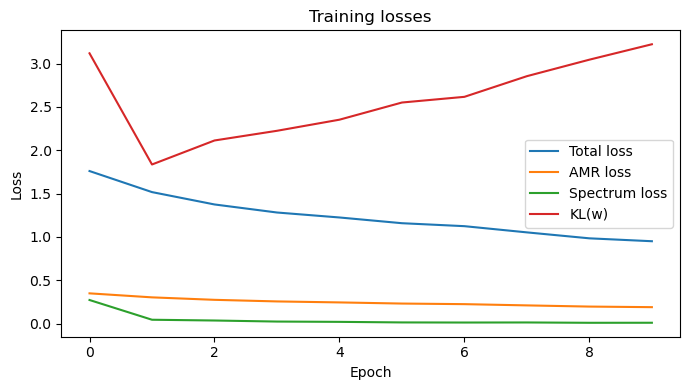

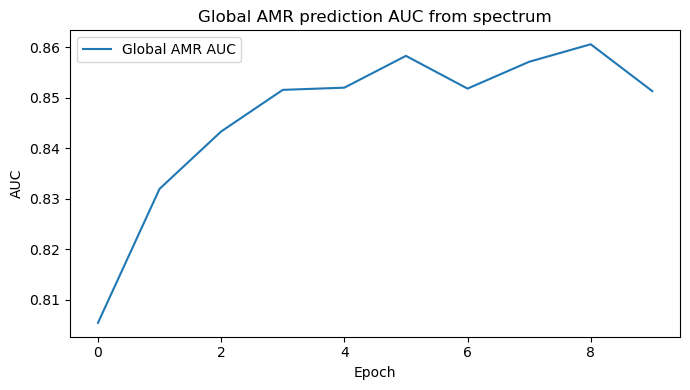

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Total loss")
plt.plot(history["train_amr_loss"], label="AMR loss")
plt.plot(history["train_spec_loss"], label="Spectrum loss")
plt.plot(history["train_kl_w"], label="KL(w)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["test_global_auc"], label="Global AMR AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Global AMR prediction AUC from spectrum")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Latent analysis: t-SNE of `w`

The latent variable `w` is inferred from the spectrum, but supervised by the AMR prediction loss.

Therefore, if the model works correctly, `w` may organize samples according to:

- AMR pattern, for example `100101`.
- Resistance burden, meaning the number of antibiotics to which a sample is resistant.
- Resistance to individual antibiotics.

Computing t-SNE of w...


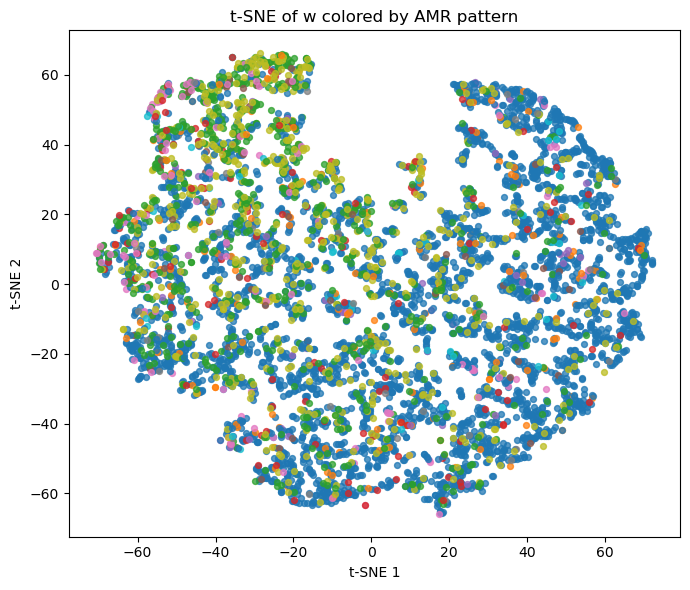

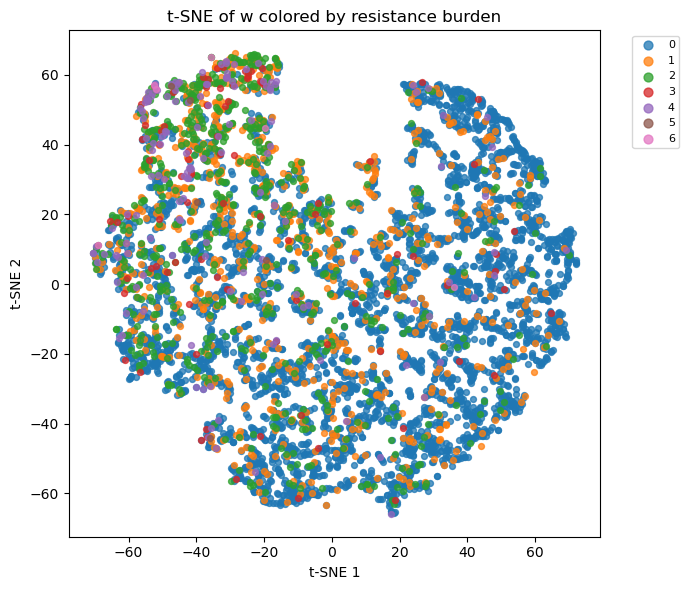

In [26]:
def amr_pattern_strings(y):
    patterns = []
    for row in y:
        chars = []
        for v in row:
            if np.isnan(v):
                chars.append("?")
            else:
                chars.append(str(int(v)))
        patterns.append("".join(chars))
    return np.array(patterns)


def resistance_burden(y):
    return np.nansum(y, axis=1)


def plot_embedding(emb, labels, title):
    plt.figure(figsize=(7, 6))
    unique = np.unique(labels)
    for lab in unique:
        idx = labels == lab
        plt.scatter(emb[idx, 0], emb[idx, 1], s=18, alpha=0.75, label=str(lab))
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    if len(unique) <= 12:
        plt.legend(markerscale=1.5, fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


w_test = test_out["w_mu"]
y_test = test_out["y_true"]

print("Computing t-SNE of w...")
w_tsne = make_tsne(
    w_test,
    perplexity=TSNE_PERPLEXITY,
    n_iter=TSNE_N_ITER,
    seed=SEED
)

pattern_labels = amr_pattern_strings(y_test)
burden_labels = resistance_burden(y_test).astype(int)

plot_embedding(w_tsne, pattern_labels, "t-SNE of w colored by AMR pattern")
plot_embedding(w_tsne, burden_labels, "t-SNE of w colored by resistance burden")

## 13. Latent `w` colored by individual antibiotic resistance

This cell generates one figure per antibiotic.

Interpretation:

- If `w` is well structured, there may be partial separation between susceptible and resistant samples.
- If an antibiotic has very few positives or very few negatives, separation may be poor or AUC may be `nan`.

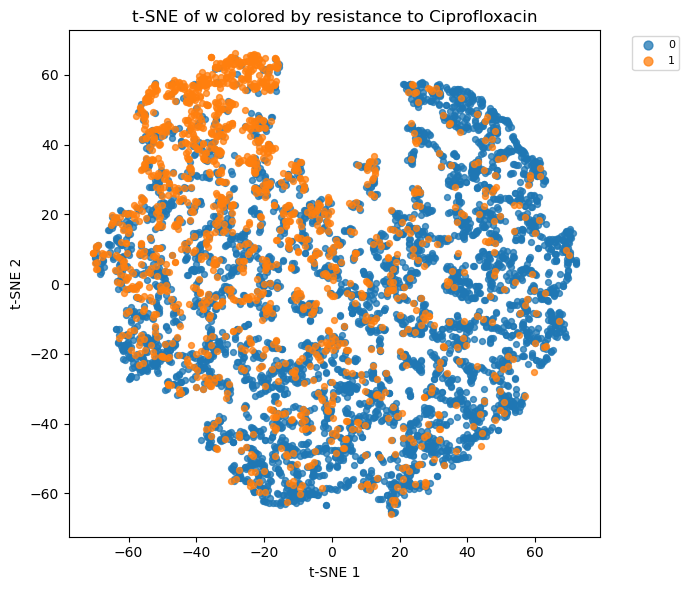

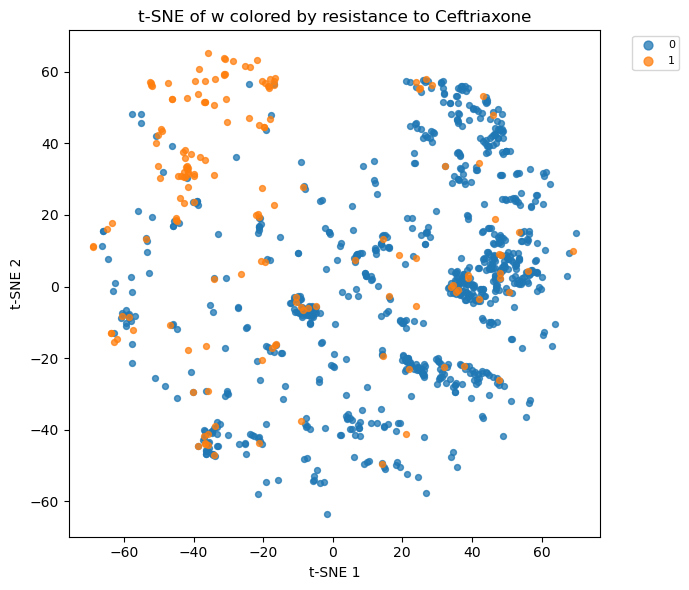

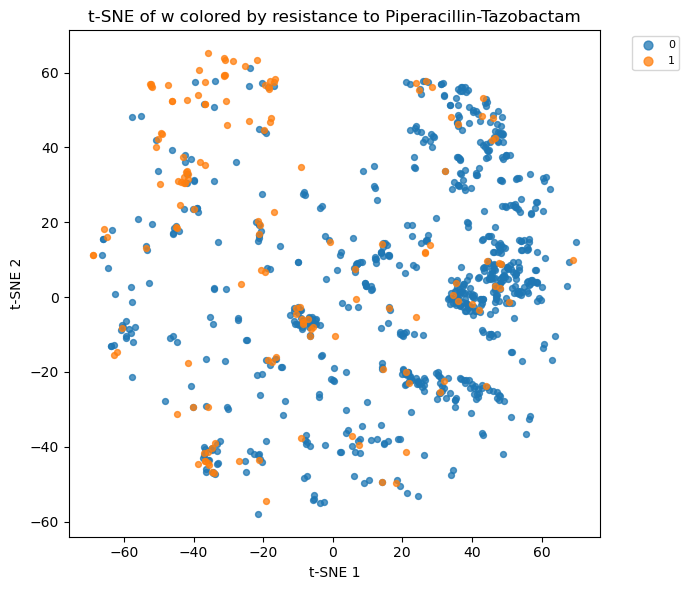

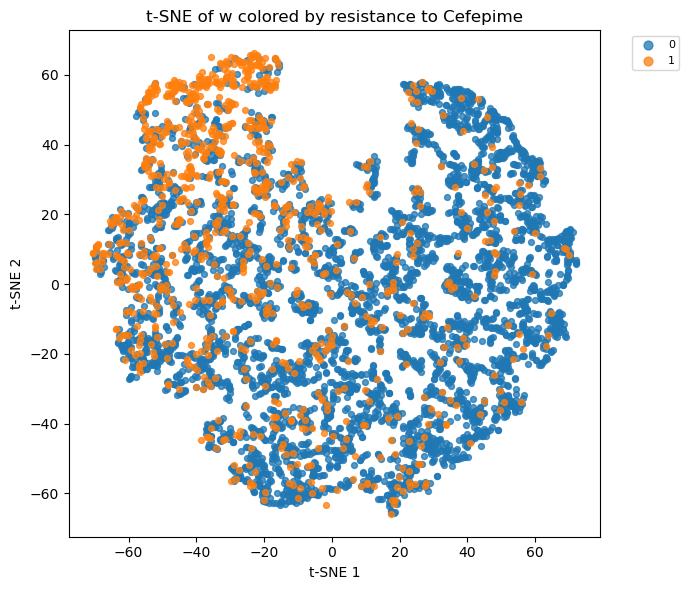

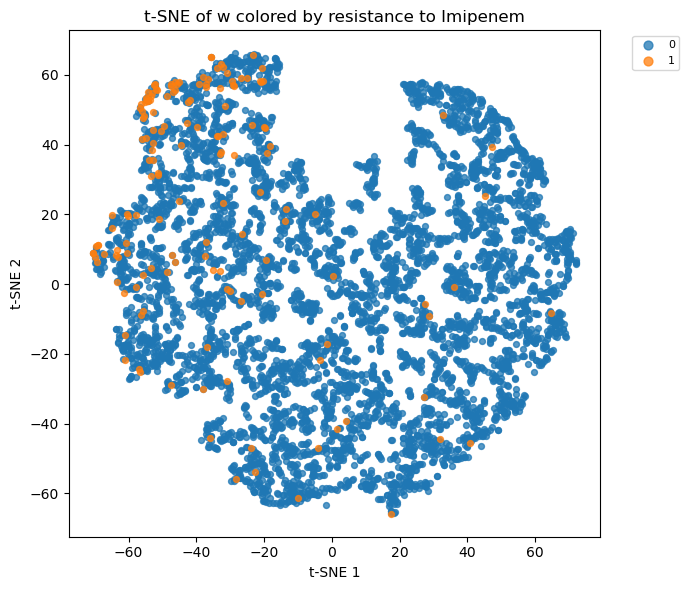

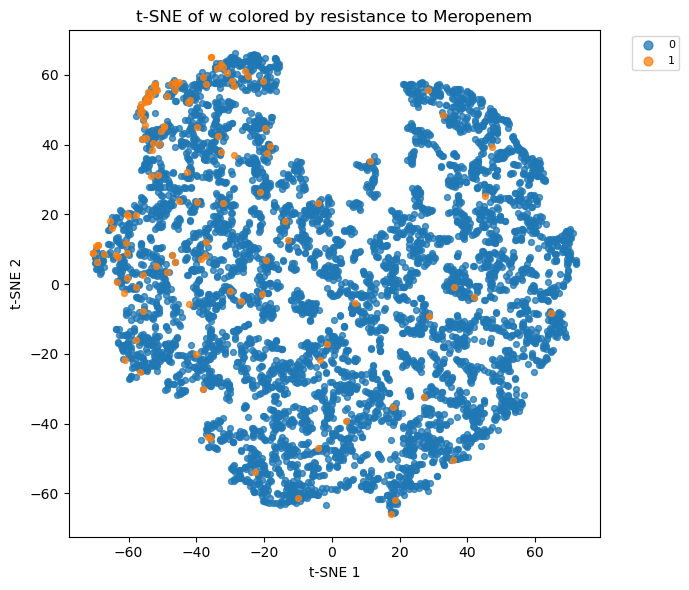

In [27]:
for j, ab in enumerate(TARGET_ANTIBIOTICS):
    labels = y_test[:, j]
    observed = ~np.isnan(labels)
    if observed.sum() == 0:
        print(f"Skipping {ab}: no observed labels")
        continue
    plot_embedding(
        w_tsne[observed],
        labels[observed].astype(int),
        f"t-SNE of w colored by resistance to {ab}"
    )

## 14. Spectrum reconstruction from resistance-oriented latent `w`

Here we compare real and reconstructed spectra.

The route is:

$$
x \rightarrow w \rightarrow \hat{x}
$$

However, `w` is not a purely spectral latent, because it is also supervised through:

$$
w \rightarrow \hat{y}
$$

Therefore, we do not necessarily expect perfect spectral reconstruction. The spectrum decoder acts as a secondary generative/regularizing constraint.

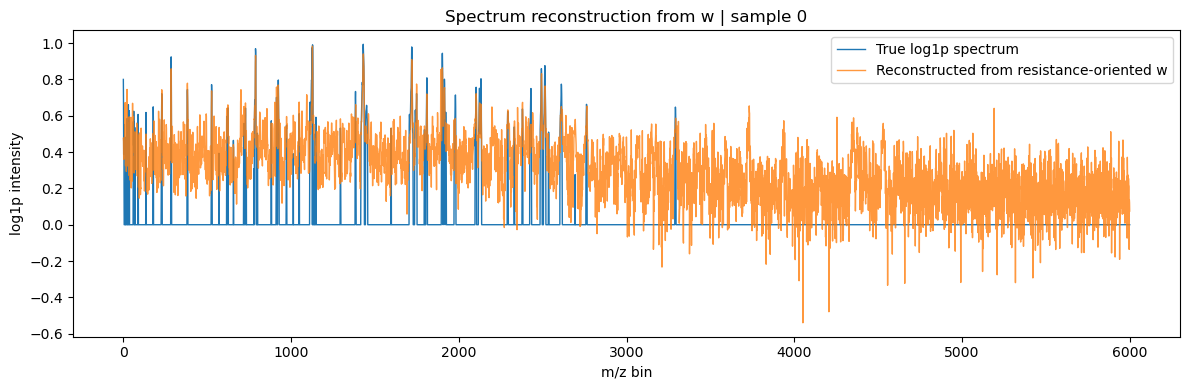

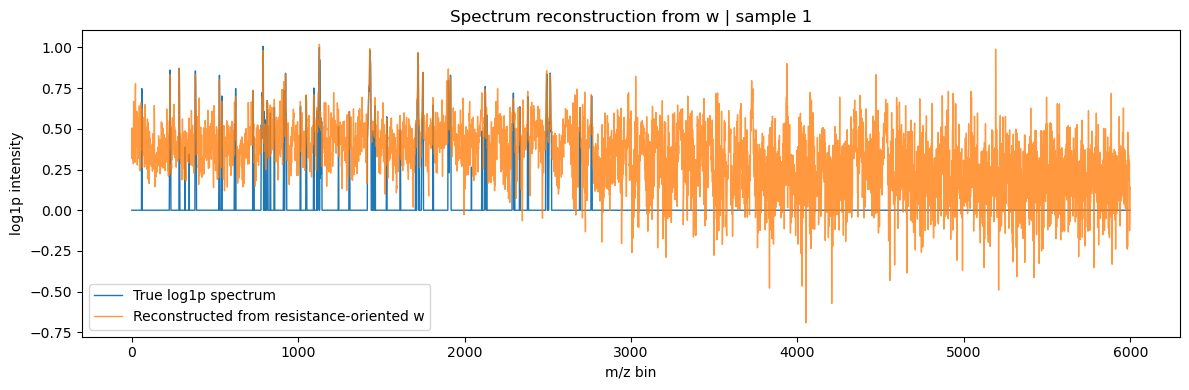

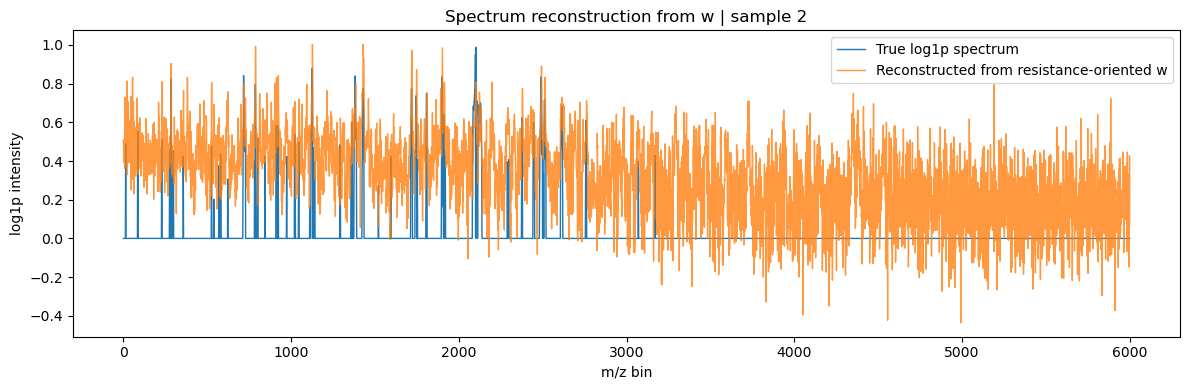

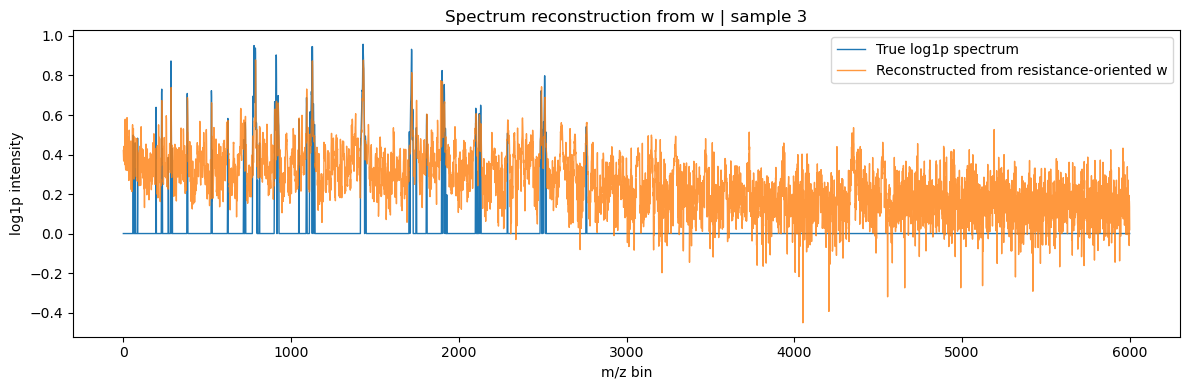

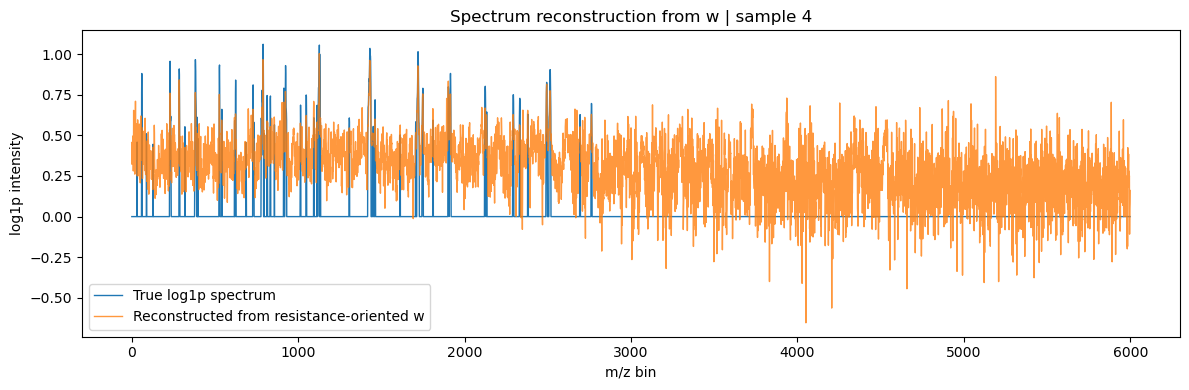

In [28]:
def plot_spectrum_reconstruction(test_out, sample_idx=0):
    x_true = test_out["x_true"][sample_idx]
    x_rec = test_out["x_mu"][sample_idx]

    plt.figure(figsize=(12, 4))
    plt.plot(x_true, label="True log1p spectrum", linewidth=1)
    plt.plot(x_rec, label="Reconstructed from resistance-oriented w", linewidth=1, alpha=0.8)
    plt.xlabel("m/z bin")
    plt.ylabel("log1p intensity")
    plt.title(f"Spectrum reconstruction from w | sample {sample_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()


for idx in range(min(5, len(test_out["x_true"]))):
    plot_spectrum_reconstruction(test_out, sample_idx=idx)